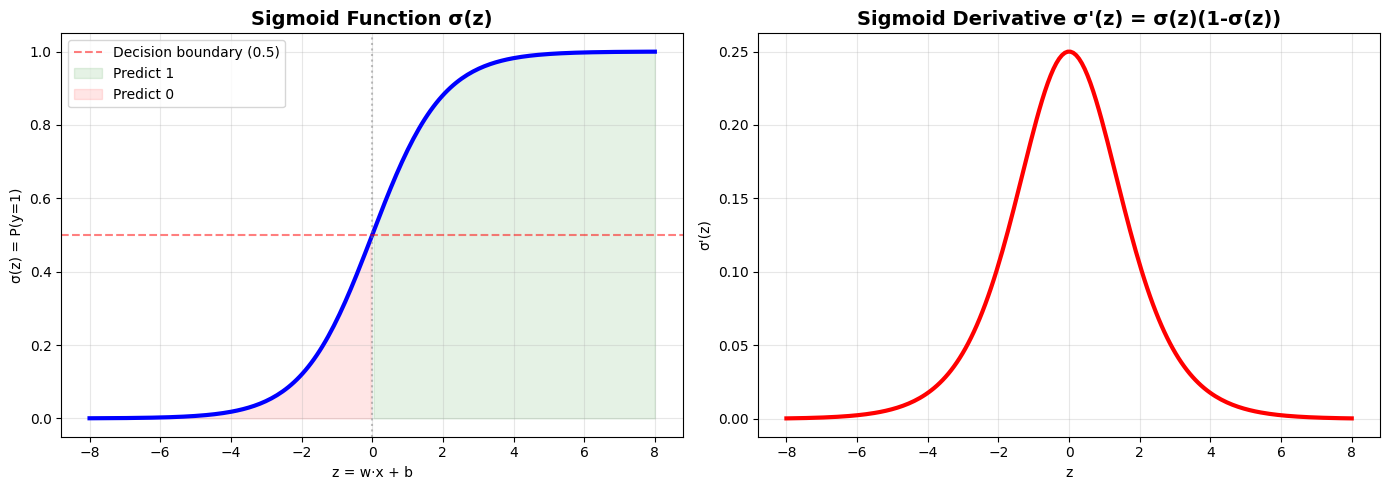

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid
axes[0].plot(z, sigmoid(z), 'b-', linewidth=3)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].fill_between(z, 0, sigmoid(z), where=(sigmoid(z) > 0.5), alpha=0.1, color='green', label='Predict 1')
axes[0].fill_between(z, 0, sigmoid(z), where=(sigmoid(z) <= 0.5), alpha=0.1, color='red', label='Predict 0')
axes[0].set_title('Sigmoid Function σ(z)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('z = w·x + b')
axes[0].set_ylabel('σ(z) = P(y=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Derivative
axes[1].plot(z, sigmoid(z) * (1 - sigmoid(z)), 'r-', linewidth=3)
axes[1].set_title("Sigmoid Derivative σ'(z) = σ(z)(1-σ(z))", fontsize=14, fontweight='bold')
axes[1].set_xlabel('z')
axes[1].set_ylabel("σ'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sigmoid.png', dpi=150)
plt.show()

Accuracy: 84.00%
Weights: [ 1.7036 -0.2961]
Bias: 0.0491


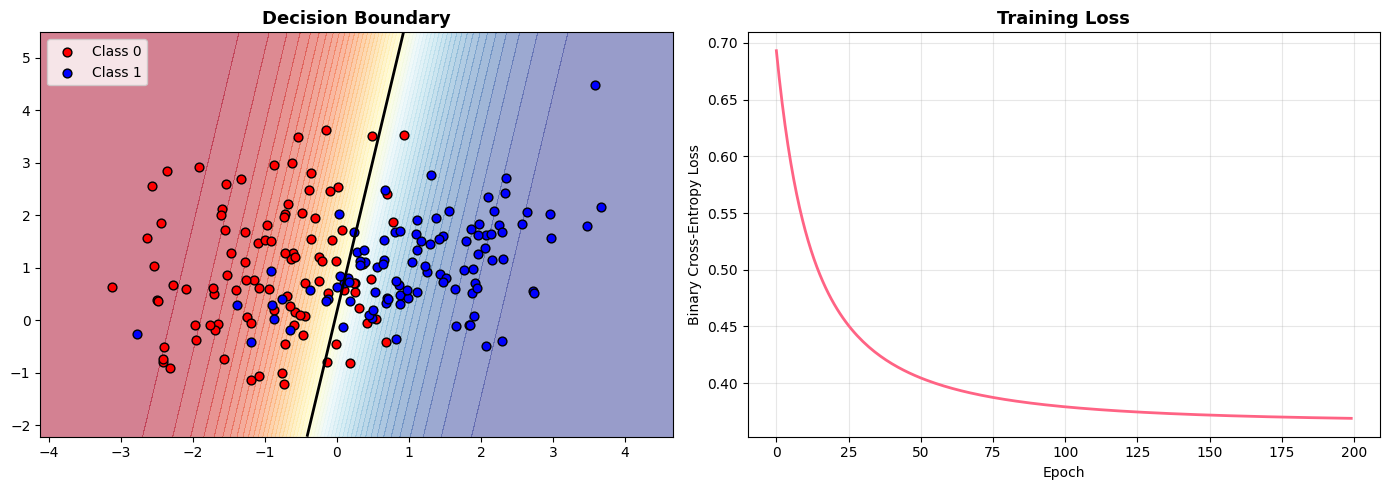

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# Generate 2D classification data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Gradient Descent for Logistic Regression
n_samples, n_features = X.shape
weights = np.zeros(n_features)
bias = 0
lr = 0.1
losses = []

for epoch in range(200):
    # Forward pass
    z = X @ weights + bias
    predictions = sigmoid(z)
    
    # Binary cross-entropy loss
    loss = -np.mean(y * np.log(predictions + 1e-8) + (1 - y) * np.log(1 - predictions + 1e-8))
    losses.append(loss)
    
    # Gradients
    dw = (1/n_samples) * X.T @ (predictions - y)
    db = (1/n_samples) * np.sum(predictions - y)
    
    # Update
    weights -= lr * dw
    bias -= lr * db

accuracy = np.mean((predictions >= 0.5).astype(int) == y)
print(f"Accuracy: {accuracy:.2%}")
print(f"Weights: {weights.round(4)}")
print(f"Bias: {bias:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ weights + bias).reshape(xx.shape)

axes[0].contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.5)
axes[0].scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolor='black', s=40, label='Class 0')
axes[0].scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='black', s=40, label='Class 1')
axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
axes[0].set_title('Decision Boundary', fontsize=13, fontweight='bold')
axes[0].legend()

# Loss curve
axes[1].plot(losses, color='#FF6384', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression.png', dpi=150)
plt.show()


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 90.00%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.78      0.82         9
   virginica       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



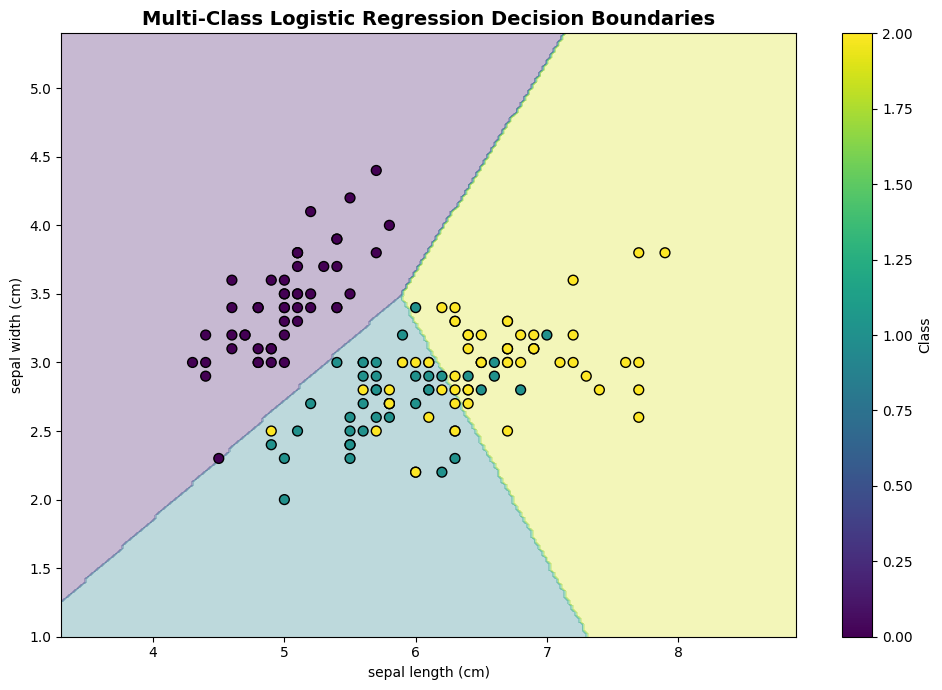

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load iris (3 classes)
iris = load_iris()
X, y = iris.data[:, :2], iris.target  # Use only 2 features for visualization

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Multinomial logistic regression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

print(f"Accuracy: {model.score(X_test, y_test):.2%}")
print(f"\n{classification_report(y_test, model.predict(X_test), target_names=iris.target_names)}")

# Visualize multi-class decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', s=50)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_title('Multi-Class Logistic Regression Decision Boundaries', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.savefig('multiclass_lr.png', dpi=150)
plt.show()

In [4]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []
        
        for _ in range(self.n_iterations):
            z = X @ self.weights + self.bias
            predictions = self._sigmoid(z)
            
            # Loss
            loss = -np.mean(y * np.log(predictions + 1e-8) + 
                          (1-y) * np.log(1 - predictions + 1e-8))
            self.losses.append(loss)
            
            # Gradients
            dw = (1/n_samples) * X.T @ (predictions - y)
            db = (1/n_samples) * np.sum(predictions - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self
    
    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Test
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=300, n_features=5, random_state=42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=500)
model.fit(X_train, y_train)
print(f"Train accuracy: {model.score(X_train, y_train):.2%}")
print(f"Test accuracy:  {model.score(X_test, y_test):.2%}")

Train accuracy: 90.83%
Test accuracy:  100.00%


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load breast cancer dataset
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train
model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# Evaluate
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print(f"Accuracy: {model.score(X_test_s, y_test):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=data.target_names)}")

Accuracy: 0.9825
ROC-AUC:  0.9954

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
from sklearn.linear_model import LogisticRegression
import numpy as np

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
for C in C_values:
    model = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000)
    model.fit(X_train_s, y_train)
    train_acc = model.score(X_train_s, y_train)
    test_acc = model.score(X_test_s, y_test)
    n_nonzero = np.sum(np.abs(model.coef_) > 0.01)
    print(f"C={C:>6}: Train={train_acc:.4f}, Test={test_acc:.4f}, Non-zero={n_nonzero}")

C= 0.001: Train=0.8879, Test=0.9298, Non-zero=27
C=  0.01: Train=0.9560, Test=0.9474, Non-zero=30
C=   0.1: Train=0.9868, Test=0.9737, Non-zero=29
C=     1: Train=0.9890, Test=0.9825, Non-zero=30
C=    10: Train=0.9912, Test=0.9649, Non-zero=30
C=   100: Train=0.9934, Test=0.9474, Non-zero=30
